In [1]:
from notebooks.utils import INPUT_PART_TO_ANNOTATION
from notebooks.figures import FONTSIZE

In [2]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained("cross-encoder/ms-marco-MiniLM-L12-v2")

NUM_HEADS = config.num_attention_heads
NUM_LAYERS = config.num_hidden_layers
HIDDEN_DIM = config.intermediate_size

print(f"NUM_HEADS: {NUM_HEADS}, NUM_LAYERS: {NUM_LAYERS}, HIDDEN_DIM: {HIDDEN_DIM}")

/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


NUM_HEADS: 12, NUM_LAYERS: 12, HIDDEN_DIM: 1536


Loading: /home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/ad365887609e0da1ff8a45a22a63e1f799c58dc61ba54b5d9e32ec35ea44e385/ablation_schemes_at_percentage0.01_msmarco_intersection.pkl
Loading: /home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/ad365887609e0da1ff8a45a22a63e1f799c58dc61ba54b5d9e32ec35ea44e385/ablation_schemes_at_percentage0.01_msmarco_fusion.pkl
Loading: /home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/ad365887609e0da1ff8a45a22a63e1f799c58dc61ba54b5d9e32ec35ea44e385/ablation_schemes_at_percentage0.01_OOD_intersection.pkl
Loading: /home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/ad365887609e0da1ff8a45a22a63e1f799c58dc61ba54b5d9e32ec35ea44e385/ablation_schemes_at_percentage0.01_OOD_fusion.pkl
Loading: /home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationsch

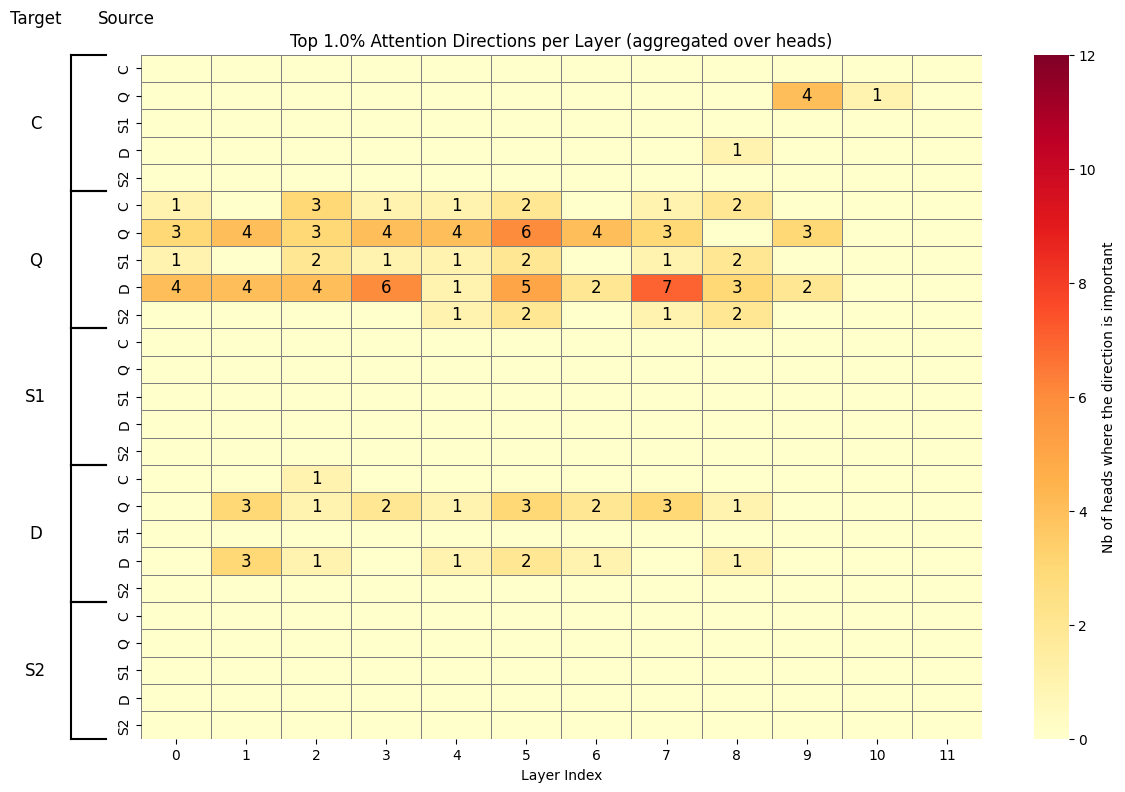

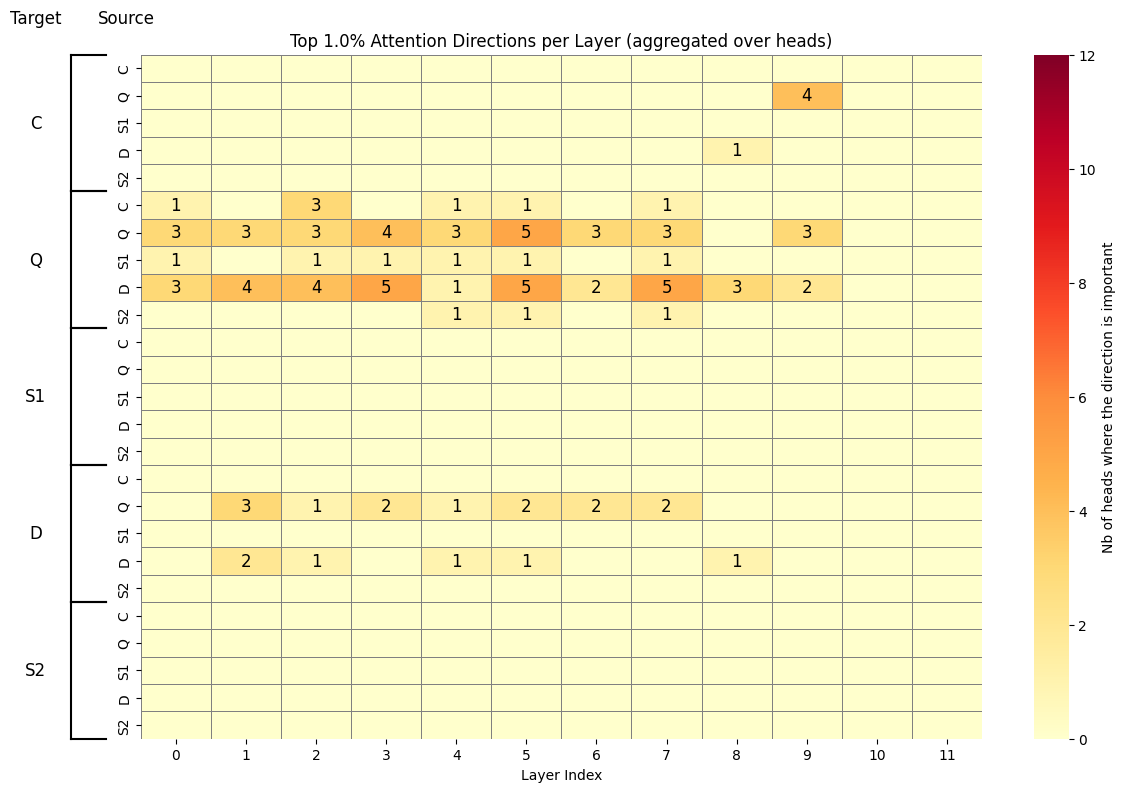

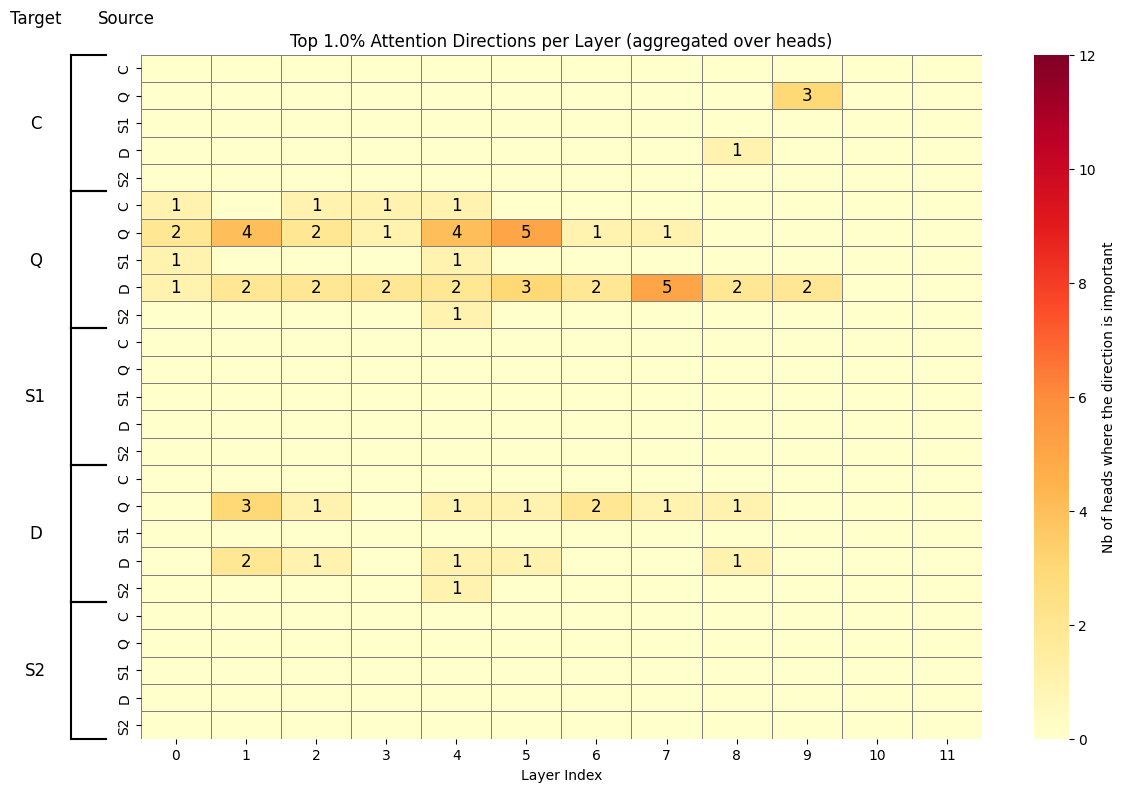

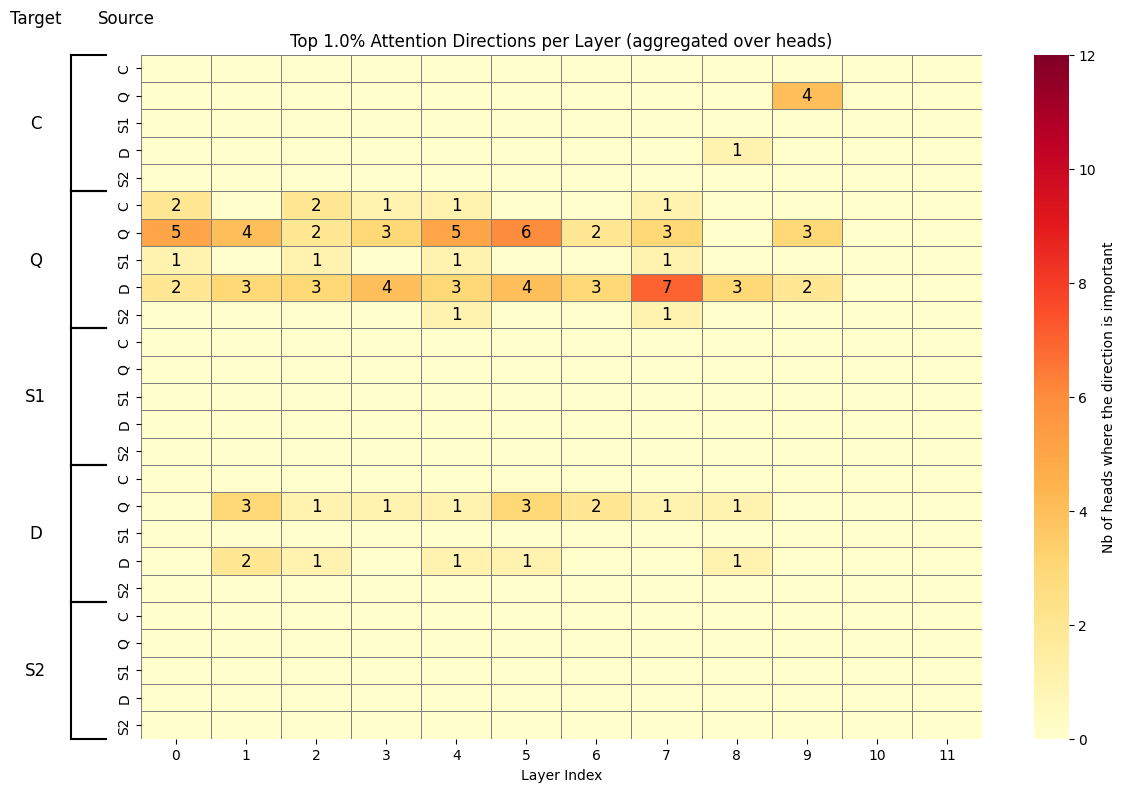

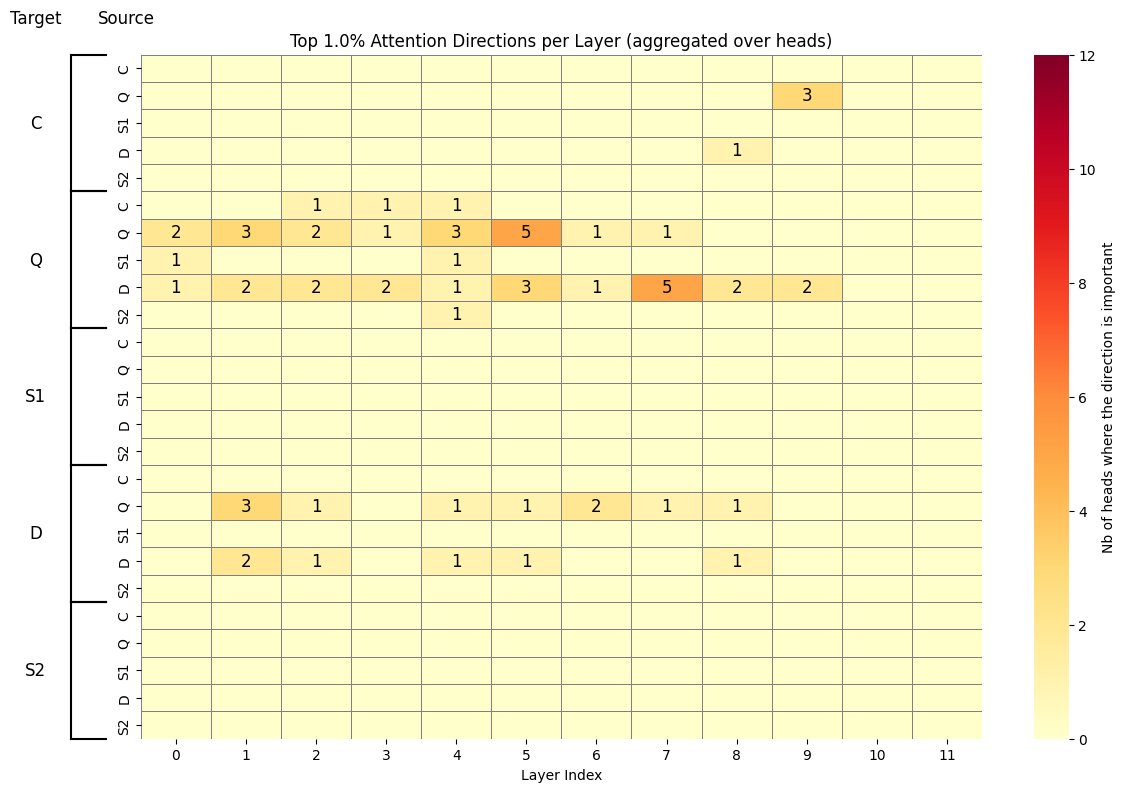

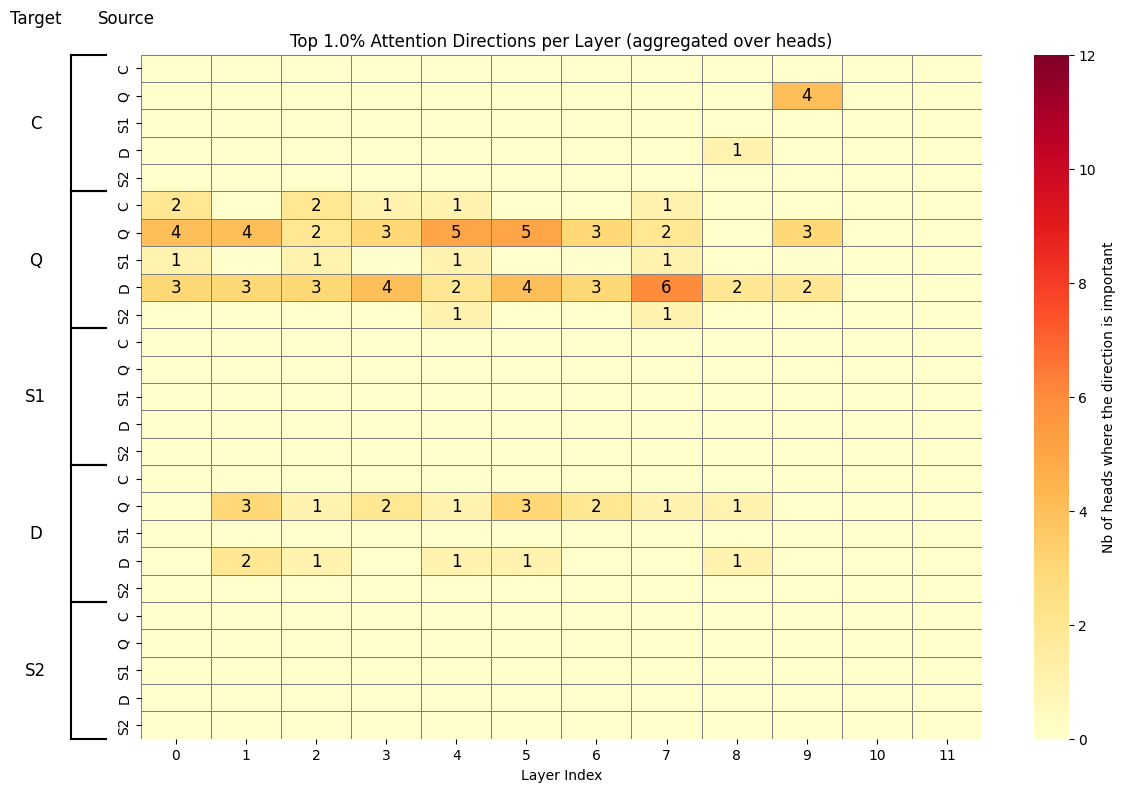

In [3]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import defaultdict

for name in ["msmarco_intersection", "msmarco_fusion", "OOD_intersection", "OOD_fusion", "ALL_intersection", "ALL_fusion"]:
    for percentage in [0.01]:

        path = f"/home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/ad365887609e0da1ff8a45a22a63e1f799c58dc61ba54b5d9e32ec35ea44e385/ablation_schemes_at_percentage{percentage}_{name}.pkl"
        print("Loading:", path)
        # Load pickle file
        with open(path, 'rb') as f:
            data = pickle.load(f)

        # Define the 25 possible direction keys
        directions = [(a, b) for a in INPUT_PART_TO_ANNOTATION.keys() for b in INPUT_PART_TO_ANNOTATION.keys()]
        direction_to_idx = {f"{a}_{b}": i for i, (a, b) in enumerate(directions)}

        # Pattern to extract layer index
        pattern = re.compile(r'bert\.encoder\.layer\.(\d+)\.attention\.self\.attention_probs\.(\d+)')

        # Organize head info by layer
        layer_heads = defaultdict(list)

        for key, direction_dict in data.items():
            match = pattern.match(key)
            if match:
                layer_idx = int(match.group(1))
                layer_heads[layer_idx].append(direction_dict)
        expected_layers = list(range(NUM_LAYERS)) 

        # Prepare heatmap matrix: (num_directions, num_layers)
        num_layers = len(expected_layers)
        num_directions = len(directions)
        heatmap_matrix = np.zeros((num_directions, num_layers), dtype=int)

        # Fill matrix
        for col_idx, layer_idx in enumerate(expected_layers):
            for head in layer_heads.get(layer_idx, []):  # use get to handle missing layers
                for direction_key, value in head.items():
                    if value.size > 0:  # Important direction
                        row_idx = direction_to_idx[direction_key]
                        heatmap_matrix[row_idx][col_idx] += 1

        # Plotting
        yticks = [s for s in INPUT_PART_TO_ANNOTATION.values()]
        fig, ax = plt.subplots(figsize=(12, 8))
        for i in range(heatmap_matrix.T.shape[0]):
            for j in range(heatmap_matrix.T.shape[1]):
                if int(heatmap_matrix.T[i, j].item()) > 0:
                    ax.text(i + 0.5, j + 0.5, str(int(heatmap_matrix.T[i, j].item())), 
                            ha='center', va='center', color='black', fontsize=FONTSIZE)
        sns.heatmap(
            heatmap_matrix, 
            xticklabels=range(num_layers),
            yticklabels=yticks * 5,
            vmin=0, vmax=NUM_HEADS,
            cmap="YlOrRd",  
            cbar_kws={"label": "Nb of heads where the direction is important"},
            linewidths=0.5,
            linecolor='gray',
            ax=ax
        )
        plt.xlabel("Layer Index")
        plt.title(f"Top {percentage * 100}% Attention Directions per Layer (aggregated over heads)")

        # Custom tick labels
        # --------- Add brackets and centered target labels ---------
        for i, target in enumerate(INPUT_PART_TO_ANNOTATION.values()):
            y_start = i * 5
            y_end = y_start + 5
            y_center = y_start + 2.5

            # Bracket on the left
            ax.plot([-1., -1.], [y_start, y_end], color='black', lw=1.5, clip_on=False)
            ax.plot([-1., -0.5], [y_start, y_start], color='black', lw=1.5, clip_on=False)
            ax.plot([-1., -0.5], [y_end, y_end],     color='black', lw=1.5, clip_on=False)

            # Target label centered
            ax.text(-1.5, y_center, target, va='center', ha='center', fontsize=FONTSIZE)

        # --------- Add column headers: "Target" and "Source" ---------
        # These are positioned in data coordinates (x=-2.5 and x=-0.5)
        ax.text(-1.5, -1, "Target", ha='center', va='bottom', fontsize=FONTSIZE)
        ax.text(-0.2, -1, "Source", ha='center', va='bottom', fontsize=FONTSIZE)

        plt.tight_layout()
        plt.savefig(f"./images/minilm_nig_ATTN_{name}_{percentage}.pdf", format='pdf')

Loading: /home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/ad365887609e0da1ff8a45a22a63e1f799c58dc61ba54b5d9e32ec35ea44e385/ablation_schemes_at_percentage0.01_msmarco_intersection.pkl


Loading: /home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/ad365887609e0da1ff8a45a22a63e1f799c58dc61ba54b5d9e32ec35ea44e385/ablation_schemes_at_percentage0.01_msmarco_fusion.pkl
Loading: /home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/ad365887609e0da1ff8a45a22a63e1f799c58dc61ba54b5d9e32ec35ea44e385/ablation_schemes_at_percentage0.01_OOD_intersection.pkl
Loading: /home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/ad365887609e0da1ff8a45a22a63e1f799c58dc61ba54b5d9e32ec35ea44e385/ablation_schemes_at_percentage0.01_OOD_fusion.pkl
Loading: /home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/ad365887609e0da1ff8a45a22a63e1f799c58dc61ba54b5d9e32ec35ea44e385/ablation_schemes_at_percentage0.01_ALL_intersection.pkl
Loading: /home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes

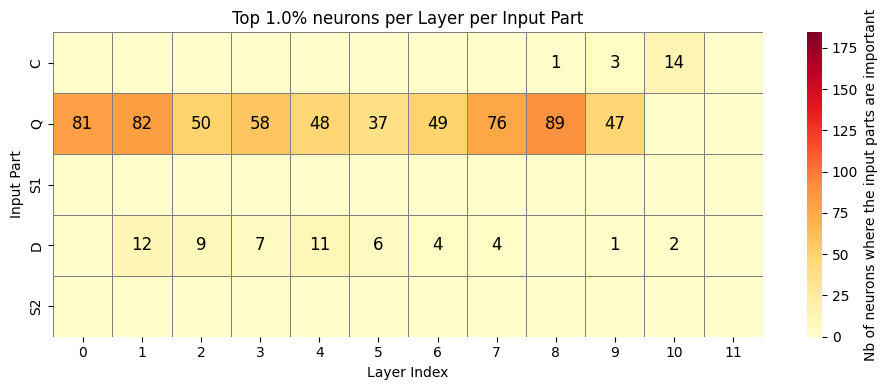

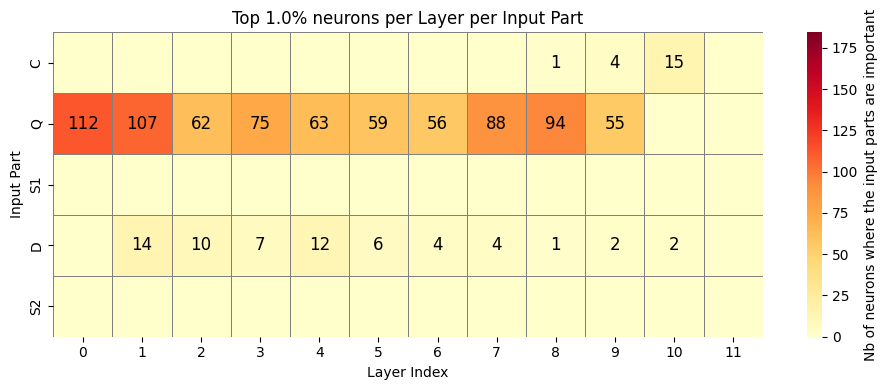

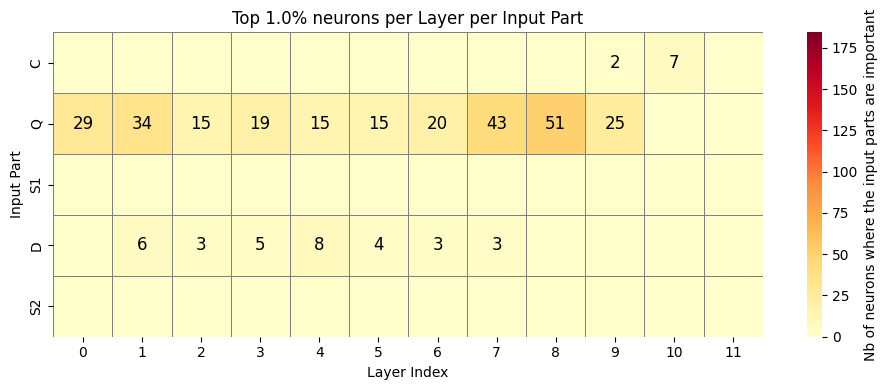

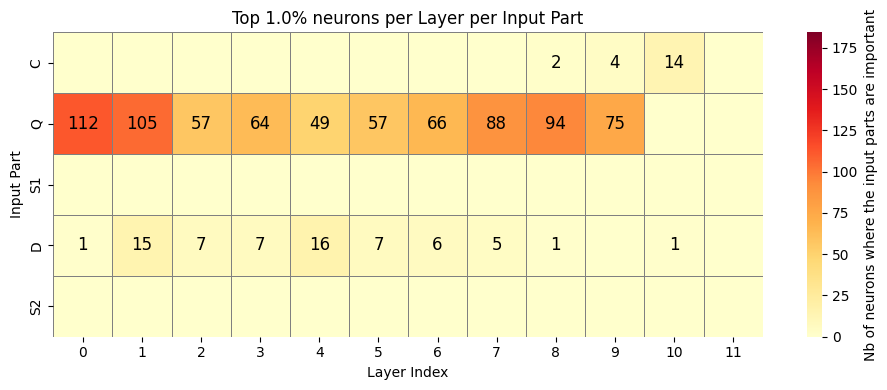

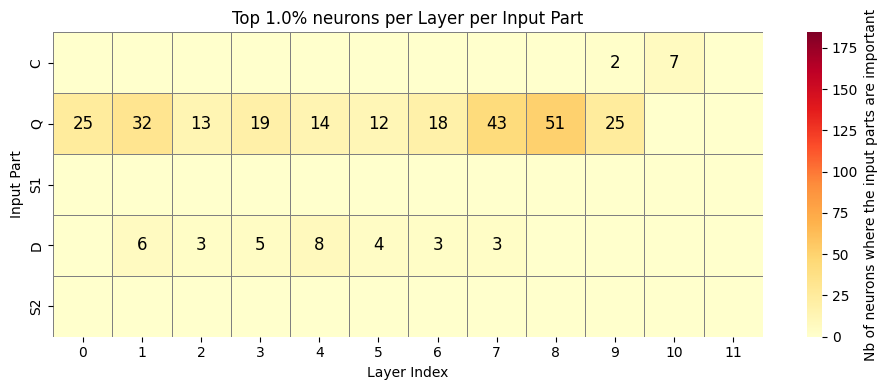

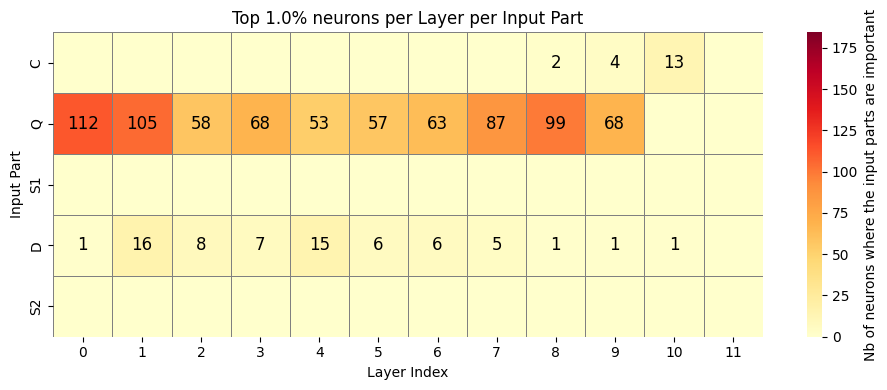

In [4]:
for name in ["msmarco_intersection", "msmarco_fusion", "OOD_intersection", "OOD_fusion", "ALL_intersection", "ALL_fusion"]:
    for percentage in [0.01]:

        path = f"/home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/ad365887609e0da1ff8a45a22a63e1f799c58dc61ba54b5d9e32ec35ea44e385/ablation_schemes_at_percentage{percentage}_{name}.pkl"
        print("Loading:", path)
        # Load pickle file
        with open(path, 'rb') as f:
            data = pickle.load(f)

        # Define the 25 possible direction keys
        directions = [a for a in INPUT_PART_TO_ANNOTATION.keys()]
        direction_to_idx = {f"{a}": i for i, a in enumerate(directions)}

        # Pattern to extract layer index
        pattern = re.compile(r'bert\.encoder\.layer\.(\d+)\.intermediate\.dense')

        # Organize head info by layer
        layer_heads = defaultdict(list)

        for key, direction_dict in data.items():
            match = pattern.match(key)
            if match:
                layer_idx = int(match.group(1))
                layer_heads[layer_idx].append(direction_dict)

        expected_layers = list(range(NUM_LAYERS))

        # Prepare heatmap matrix: (num_directions, num_layers)
        num_layers = len(expected_layers)
        num_directions = len(directions)
        heatmap_matrix = np.zeros((num_directions, num_layers), dtype=int)

        # Fill matrix
        for col_idx, layer_idx in enumerate(expected_layers):
            for head in layer_heads.get(layer_idx, []):  # use get to handle missing layers
                for direction_key, value in head.items():
                    if value.size > 0:  # Important direction
                        row_idx = direction_to_idx[direction_key]
                        heatmap_matrix[row_idx][col_idx] += value.size

        # Plotting
        yticks = [s for s in INPUT_PART_TO_ANNOTATION.values()]

        cell_width = 0.8
        cell_height = 0.8

        # Compute figure size
        fig_width = cell_width * heatmap_matrix.shape[1]
        fig_height = cell_height * heatmap_matrix.shape[0]
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        for i in range(heatmap_matrix.T.shape[0]):
            for j in range(heatmap_matrix.T.shape[1]):
                if int(heatmap_matrix.T[i, j].item()) > 0:
                    ax.text(i + 0.5, j + 0.5, str(int(heatmap_matrix.T[i, j].item())), 
                            ha='center', va='center', color='black', fontsize=FONTSIZE)
        sns.heatmap(
            heatmap_matrix, 
            xticklabels=range(num_layers),
            yticklabels=yticks,
            vmin=0, vmax=num_layers * HIDDEN_DIM * percentage,
            cmap="YlOrRd",  
            cbar_kws={"label": "Nb of neurons where the input parts are important"},
            linewidths=0.5,
            linecolor='gray',
            ax=ax
        )
        plt.xlabel("Layer Index")
        plt.ylabel("Input Part")
        plt.title(f"Top {percentage * 100}% neurons per Layer per Input Part")

        plt.tight_layout()
        plt.savefig(f"./images/minilm_nig_FFN_{name}_{percentage}.pdf", format='pdf')